###import libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

###Load Dataset

In [ ]:
df = pd.read_csv('analysis data.csv')

###Convert Date column

In [ ]:
df['order_purchase_timestamp'] = pd.to_datetime(
    df['order_purchase_timestamp']
)

###Create Monthly Revenue Table

In [ ]:
monthly_revenue = (
    df.groupby(
        df['order_purchase_timestamp']
        .dt.to_period('M')
    )['revenue']
    .sum()
    .reset_index()
)

monthly_revenue.columns = [
    'Month',
    'Revenue'
]

monthly_revenue['Month'] = (
    monthly_revenue['Month']
    .astype(str)
)

monthly_revenue

,Month,Revenue
0,2016-09,72.89
1,2016-10,4336.30
2,2017-01,13286.43
3,2017-02,22384.87
4,2017-03,37921.52
5,2017-04,37053.01
6,2017-05,54659.47
7,2017-06,45713.44
8,2017-07,51449.15
9,2017-08,61571.17


###Revenue Growth Table

In [ ]:
monthly_revenue[
    'Growth_Rate_%'
] = (
    monthly_revenue['Revenue']
    .pct_change()
) * 100

monthly_revenue

,Month,Revenue,Growth_Rate_%
0,2016-09,72.89,NaN
1,2016-10,4336.30,5849.101386
2,2017-01,13286.43,206.400157
3,2017-02,22384.87,68.479193
4,2017-03,37921.52,69.406925
5,2017-04,37053.01,-2.290283
6,2017-05,54659.47,47.516949
7,2017-06,45713.44,-16.366844
8,2017-07,51449.15,12.547098
9,2017-08,61571.17,19.673833


###Monthly Revenue Trend Graph

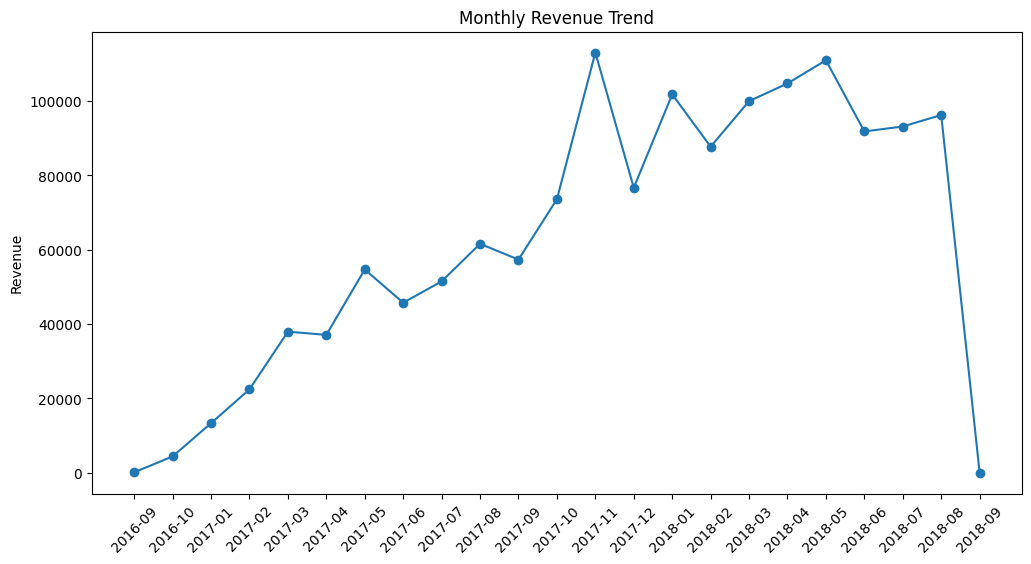

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_revenue['Month'],
    monthly_revenue['Revenue'],
    marker='o'
)

plt.xticks(rotation=45)

plt.title(
    'Monthly Revenue Trend'
)

plt.ylabel('Revenue')

plt.show()

###Build Forecast Model

In [ ]:
monthly_revenue['Month_Number'] = range(
    len(monthly_revenue)
)

In [ ]:
X = monthly_revenue[
    ['Month_Number']
]

y = monthly_revenue['Revenue']

model = LinearRegression()

model.fit(X,y)

LinearRegression()

###Forecast Next 6 Months

In [ ]:
future_months = pd.DataFrame({

    'Month_Number': range(
        len(monthly_revenue),
        len(monthly_revenue)+6
    )
})

future_months[
    'Forecast_Revenue'
] = model.predict(
    future_months
)

future_months

,Month_Number,Forecast_Revenue
0,23,106772.189526
1,24,110469.099160
2,25,114166.008794
3,26,117862.918429
4,27,121559.828063
5,28,125256.737698


###Create Future Dates

In [ ]:
last_month = pd.Period(
    monthly_revenue[
        'Month'
    ].iloc[-1],
    freq='M'
)

future_dates = []

for i in range(1,7):

    future_dates.append(
        str(last_month+i)
    )

future_months['Month'] = future_dates

###Forecast Revenue Table

In [ ]:
forecast_table = future_months[
    ['Month',
     'Forecast_Revenue']
]

forecast_table

,Month,Forecast_Revenue
0,2018-10,106772.189526
1,2018-11,110469.099160
2,2018-12,114166.008794
3,2019-01,117862.918429
4,2019-02,121559.828063
5,2019-03,125256.737698


###Revenue Forecast Graph

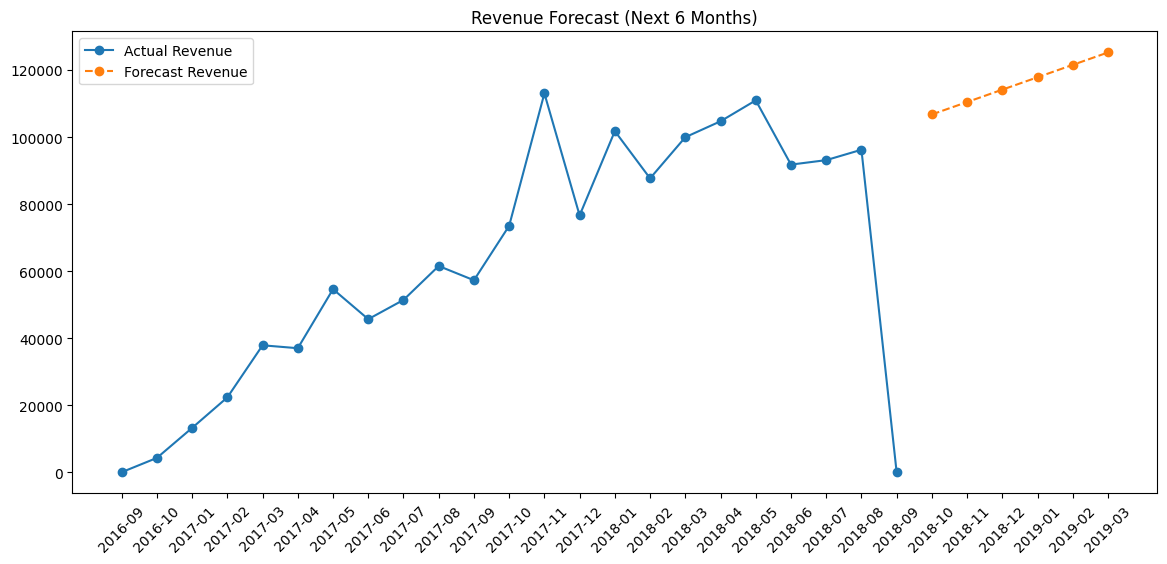

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_revenue['Month'],
    monthly_revenue['Revenue'],
    label='Actual Revenue',
    marker='o'
)

plt.plot(
    future_months['Month'],
    future_months[
        'Forecast_Revenue'
    ],
    linestyle='--',
    marker='o',
    label='Forecast Revenue'
)

plt.xticks(rotation=45)

plt.legend()

plt.title(
    'Revenue Forecast (Next 6 Months)'
)

plt.show()

###Final Business Insights

In [ ]:
avg_growth = (
    monthly_revenue[
        'Growth_Rate_%'
    ].mean()
)

print(
    f"Average Monthly Growth: {avg_growth:.2f}%"
)

Average Monthly Growth: 283.12%


In [ ]:
# Total Historical Revenue
total_revenue = monthly_revenue['Revenue'].sum()

# Average Monthly Revenue
avg_monthly_revenue = monthly_revenue['Revenue'].mean()

# Highest Revenue Month
highest_month = monthly_revenue.loc[
    monthly_revenue['Revenue'].idxmax(),
    'Month'
]

highest_revenue = monthly_revenue['Revenue'].max()

# Lowest Revenue Month
lowest_month = monthly_revenue.loc[
    monthly_revenue['Revenue'].idxmin(),
    'Month'
]

lowest_revenue = monthly_revenue['Revenue'].min()

# Average Monthly Growth
avg_growth = monthly_revenue[
    'Growth_Rate_%'
].mean()

# Next Month Forecast
next_month_forecast = future_months[
    'Forecast_Revenue'
].iloc[0]

# Total Forecast Revenue (6 Months)
forecast_6_months = future_months[
    'Forecast_Revenue'
].sum()

# Trend
if future_months['Forecast_Revenue'].iloc[-1] > future_months['Forecast_Revenue'].iloc[0]:
    trend = 'Increasing'
elif future_months['Forecast_Revenue'].iloc[-1] < future_months['Forecast_Revenue'].iloc[0]:
    trend = 'Decreasing'
else:
    trend = 'Stable'

# Conclusion Table
conclusion_table = pd.DataFrame({

    'Metric': [
        'Total Historical Revenue',
        'Average Monthly Revenue',
        'Highest Revenue Month',
        'Highest Revenue',
        'Lowest Revenue Month',
        'Lowest Revenue',
        'Average Monthly Growth (%)',
        'Next Month Forecast',
        '6 Month Forecast Revenue',
        'Forecast Trend'
    ],

    'Value': [
        round(total_revenue,2),
        round(avg_monthly_revenue,2),
        highest_month,
        round(highest_revenue,2),
        lowest_month,
        round(lowest_revenue,2),
        round(avg_growth,2),
        round(next_month_forecast,2),
        round(forecast_6_months,2),
        trend
    ]
})

conclusion_table

,Metric,Value
0,Total Historical Revenue,1435413.3
1,Average Monthly Revenue,62409.27
2,Highest Revenue Month,2017-11
3,Highest Revenue,113050.96
4,Lowest Revenue Month,2018-09
5,Lowest Revenue,0.0
6,Average Monthly Growth (%),283.12
7,Next Month Forecast,106772.19
8,6 Month Forecast Revenue,696086.78
9,Forecast Trend,Increasing


In [ ]:
conclusion_table.to_csv(
    'Revenue_Forecast_Conclusion.csv',
    index=False
)

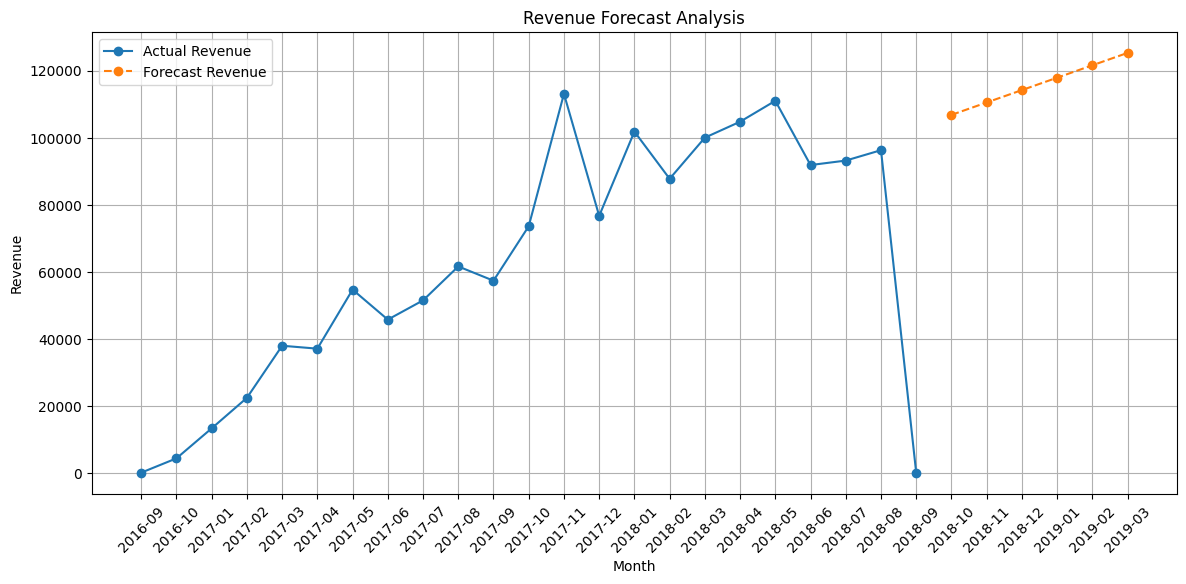

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_revenue['Month'],
    monthly_revenue['Revenue'],
    marker='o',
    label='Actual Revenue'
)

plt.plot(
    future_months['Month'],
    future_months['Forecast_Revenue'],
    marker='o',
    linestyle='--',
    label='Forecast Revenue'
)

plt.title('Revenue Forecast Analysis')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

###State Revenue Summary

In [ ]:
state_revenue = (
    df.groupby('customer_state')
    ['revenue']
    .sum()
    .reset_index()
    .sort_values(
        'revenue',
        ascending=False
    )
)

state_revenue

,customer_state,revenue
25,SP,554321.33
18,RJ,200124.46
10,MG,152495.78
17,PR,79086.32
22,RS,73556.73
23,SC,57224.64
4,BA,53125.45
6,DF,33982.32
8,GO,32122.51
5,CE,28792.91


###Top 10 Revenue states

In [ ]:
top10_states = state_revenue.head(10)

top10_states

,customer_state,revenue
25,SP,554321.33
18,RJ,200124.46
10,MG,152495.78
17,PR,79086.32
22,RS,73556.73
23,SC,57224.64
4,BA,53125.45
6,DF,33982.32
8,GO,32122.51
5,CE,28792.91


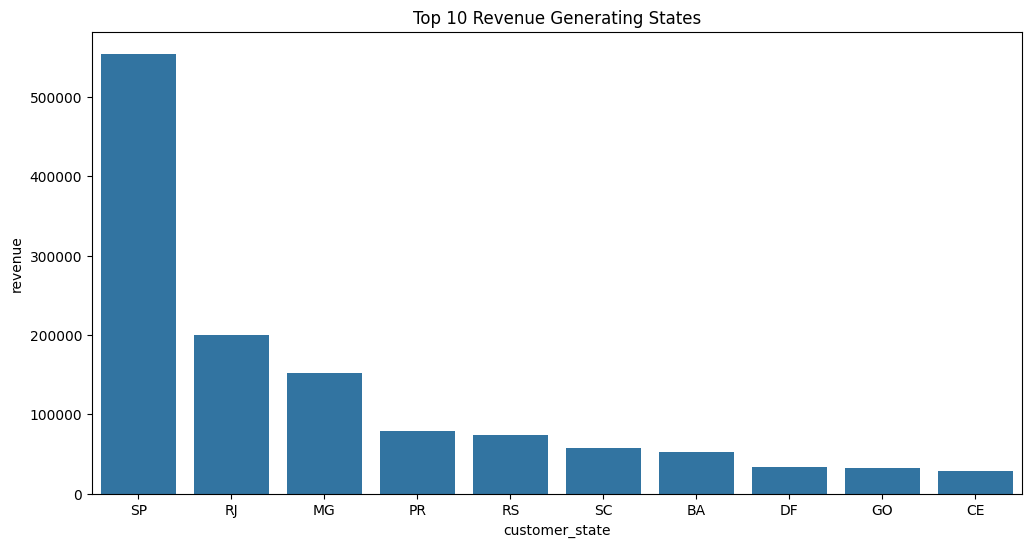

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_states,
    x='customer_state',
    y='revenue'
)

plt.title(
    'Top 10 Revenue Generating States'
)

plt.show()

###Bottom 10 Revenue states

In [ ]:
bottom10_states = (
    state_revenue
    .sort_values('revenue')
    .head(10)
)

bottom10_states

,customer_state,revenue
3,AP,214.89
21,RR,269.27
2,AM,1808.67
0,AC,2565.44
26,TO,3628.01
20,RO,3633.42
1,AL,5246.14
19,RN,7503.33
24,SE,7635.68
11,MS,9486.35


###Monthly Revenue by State

In [ ]:
top5 = (
    state_revenue
    .head(5)
    ['customer_state']
    .tolist()
)

In [ ]:
state_monthly = (
    df[
        df['customer_state']
        .isin(top5)
    ]
    .groupby([
        df[
            'order_purchase_timestamp'
        ].dt.to_period('M'),
        'customer_state'
    ])
    ['revenue']
    .sum()
    .reset_index()
)

###State Revenue Trend Graaph

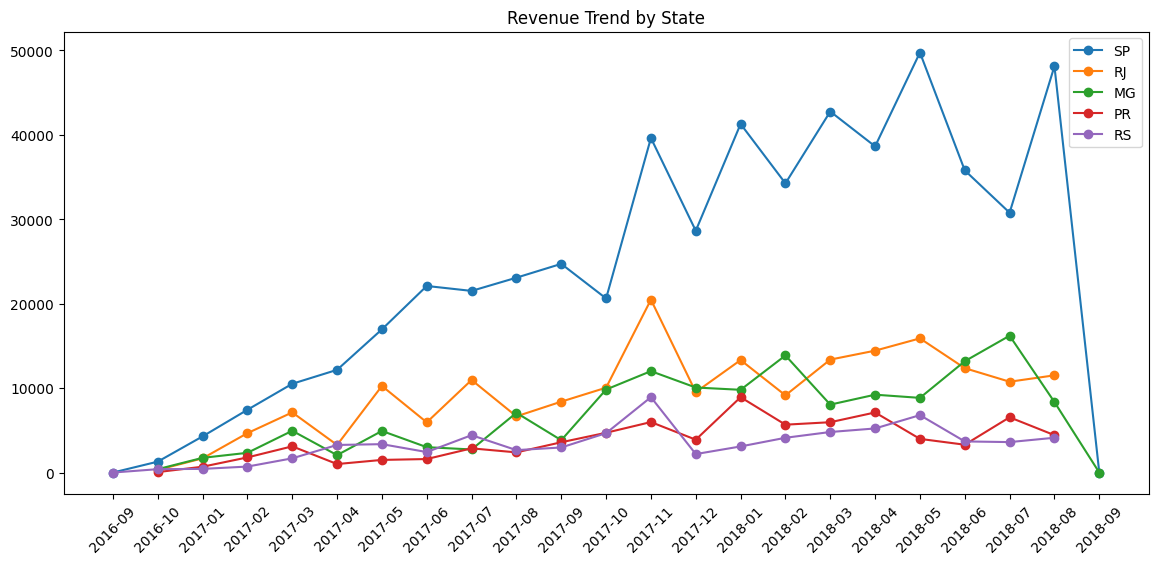

In [ ]:
state_monthly[
    'order_purchase_timestamp'
] = (
    state_monthly[
        'order_purchase_timestamp'
    ].astype(str)
)

plt.figure(figsize=(14,6))

for state in top5:

    temp = state_monthly[
        state_monthly[
            'customer_state'
        ] == state
    ]

    plt.plot(
        temp[
            'order_purchase_timestamp'
        ],
        temp['revenue'],
        marker='o',
        label=state
    )

plt.legend()

plt.xticks(rotation=45)

plt.title(
    'Revenue Trend by State'
)

plt.show()

###Forecast Revenue for Each State

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
state = 'SP'  # replace with your state

In [ ]:
temp = (
    state_monthly[
        state_monthly[
            'customer_state'
        ] == state
    ]
    .copy()
)

In [ ]:
temp['Month_Number'] = range(
    len(temp)
)

X = temp[['Month_Number']]
y = temp['revenue']

model = LinearRegression()

model.fit(X,y)

LinearRegression()

###Forecast next 6 months

In [ ]:
future = pd.DataFrame({

    'Month_Number': range(
        len(temp),
        len(temp)+6
    )
})

future['Forecast_Revenue'] = (
    model.predict(future)
)

future

,Month_Number,Forecast_Revenue
0,23,43430.592134
1,24,45041.397530
2,25,46652.202925
3,26,48263.008320
4,27,49873.813715
5,28,51484.619111


###state  revenue heatmap

In [ ]:
state_heatmap = pd.pivot_table(

    df,

    values='revenue',

    index='customer_state',

    columns=df[
        'order_purchase_timestamp'
    ].dt.year,

    aggfunc='sum'
)

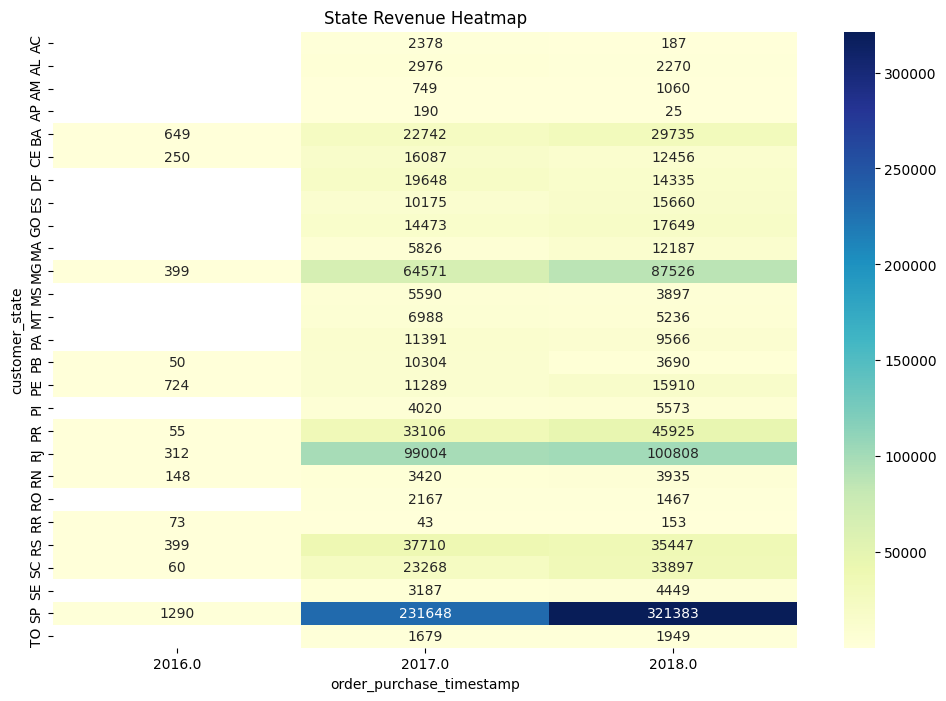

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    state_heatmap,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu'
)

plt.title(
    'State Revenue Heatmap'
)

plt.show()

In [ ]:
state_conclusion = pd.DataFrame({

    'Metric': [

        'Top Revenue State',
        'Lowest Revenue State',
        'Highest State Revenue',
        'Lowest State Revenue'

    ],

    'Value': [

        state_revenue.iloc[0]['customer_state'],

        state_revenue.iloc[-1]['customer_state'],

        round(
            state_revenue.iloc[0]['revenue'],
            2
        ),

        round(
            state_revenue.iloc[-1]['revenue'],
            2
        )
    ]
})

state_conclusion

,Metric,Value
0,Top Revenue State,SP
1,Lowest Revenue State,AP
2,Highest State Revenue,554321.33
3,Lowest State Revenue,214.89


In [ ]:
# Convert date column if not already converted
df['order_purchase_timestamp'] = pd.to_datetime(
    df['order_purchase_timestamp']
)

# Create Month column
df['Month'] = (
    df['order_purchase_timestamp']
    .dt.to_period('M')
    .astype(str)
)

# Monthly Revenue by State
monthly_state_revenue = pd.pivot_table(

    df,

    values='revenue',

    index='Month',

    columns='customer_state',

    aggfunc='sum',

    fill_value=0

)

monthly_state_revenue

customer_state,AC,AL,AM,AP,BA,CE,DF,ES,GO,MA,...,PR,RJ,RN,RO,RR,RS,SC,SE,SP,TO
Month,,,,,,,,,,,,,,,,,,,,,
2016-09,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,72.89,0.00,0.00,0.00,0.00,0.00
2016-10,0.00,0.00,0.00,0.00,649.17,249.90,0.00,0.00,0.00,0.00,...,54.99,312.49,148.00,0.00,0.00,399.00,59.90,0.00,1290.26,0.00
2017-01,0.00,129.99,0.00,0.00,1336.60,326.00,1101.90,34.90,0.00,18.00,...,689.38,1680.98,129.99,0.00,0.00,432.28,1051.88,0.00,4281.35,0.00
2017-02,0.00,0.00,0.00,0.00,324.88,683.58,279.98,732.59,244.78,0.00,...,1792.66,4664.97,35.50,774.90,26.90,707.48,951.60,269.90,7434.44,0.00
2017-03,56.99,93.80,0.00,0.00,1557.35,520.90,1750.29,509.50,1095.42,63.99,...,3103.13,7123.62,225.99,143.80,0.00,1683.14,2209.98,205.58,10512.84,140.98
2017-04,249.99,49.90,289.70,0.00,1726.70,309.69,8100.80,665.68,372.78,135.30,...,1005.63,3265.36,0.00,125.00,0.00,3266.65,861.70,216.99,12164.75,149.40
2017-05,876.00,129.89,0.00,0.00,1146.44,1848.01,1741.47,1305.42,1069.89,663.48,...,1495.56,10255.62,145.00,49.99,0.00,3362.75,2937.17,86.59,16960.68,331.70
2017-06,0.00,221.89,0.00,0.00,2111.89,904.55,383.50,497.39,1541.50,0.00,...,1598.56,5945.45,89.50,0.00,16.50,2427.10,1432.59,0.00,22098.34,278.50
2017-07,388.89,106.90,0.00,0.00,1346.08,375.99,519.20,841.02,1000.23,226.44,...,2865.26,10963.59,147.89,130.00,0.00,4425.40,699.88,0.00,21513.67,0.00


In [ ]:
top10_states = (
    df.groupby('customer_state')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

monthly_state_revenue_top10 = pd.pivot_table(

    df[
        df['customer_state']
        .isin(top10_states)
    ],

    values='revenue',

    index='Month',

    columns='customer_state',

    aggfunc='sum',

    fill_value=0

)

monthly_state_revenue_top10

customer_state,BA,CE,DF,GO,MG,PR,RJ,RS,SC,SP
Month,,,,,,,,,,
2016-09,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2016-10,649.17,249.90,0.00,0.00,398.69,54.99,312.49,399.00,59.90,1290.26
2017-01,1336.60,326.00,1101.90,0.00,1741.49,689.38,1680.98,432.28,1051.88,4281.35
2017-02,324.88,683.58,279.98,244.78,2336.42,1792.66,4664.97,707.48,951.60,7434.44
2017-03,1557.35,520.90,1750.29,1095.42,4947.06,3103.13,7123.62,1683.14,2209.98,10512.84
2017-04,1726.70,309.69,8100.80,372.78,2060.62,1005.63,3265.36,3266.65,861.70,12164.75
2017-05,1146.44,1848.01,1741.47,1069.89,4927.17,1495.56,10255.62,3362.75,2937.17,16960.68
2017-06,2111.89,904.55,383.50,1541.50,3004.49,1598.56,5945.45,2427.10,1432.59,22098.34
2017-07,1346.08,375.99,519.20,1000.23,2734.16,2865.26,10963.59,4425.40,699.88,21513.67


In [ ]:
from sklearn.linear_model import LinearRegression
import pandas as pd
import matplotlib.pyplot as plt

# Select State
state = 'SP'

# State Monthly Revenue
state_data = (
    df[df['customer_state'] == state]
    .groupby(
        df['order_purchase_timestamp']
        .dt.to_period('M')
    )['revenue']
    .sum()
    .reset_index()
)

state_data.columns = ['Month','Revenue']

state_data['Month'] = (
    state_data['Month']
    .astype(str)
)

# Create Time Index
state_data['Month_Number'] = range(
    len(state_data)
)

# Train Model
X = state_data[['Month_Number']]
y = state_data['Revenue']

model = LinearRegression()
model.fit(X,y)

# Forecast Next 6 Months
future = pd.DataFrame({

    'Month_Number': range(
        len(state_data),
        len(state_data)+6
    )
})

future['Forecast_Revenue'] = (
    model.predict(future)
)

# Create Future Months
last_month = pd.Period(
    state_data['Month'].iloc[-1],
    freq='M'
)

future['Month'] = [

    str(last_month+i)

    for i in range(1,7)
]

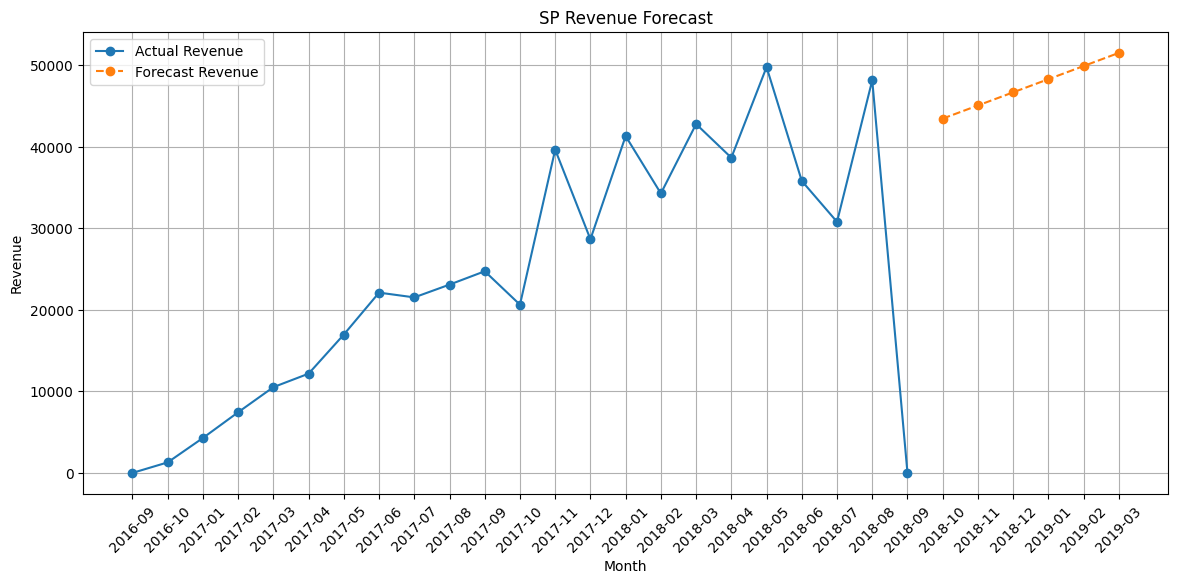

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(

    state_data['Month'],
    state_data['Revenue'],

    marker='o',

    label='Actual Revenue'
)

plt.plot(

    future['Month'],
    future['Forecast_Revenue'],

    marker='o',

    linestyle='--',

    label='Forecast Revenue'
)

plt.title(
    f'{state} Revenue Forecast'
)

plt.xlabel('Month')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
top5_states = (
    df.groupby('customer_state')
    ['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

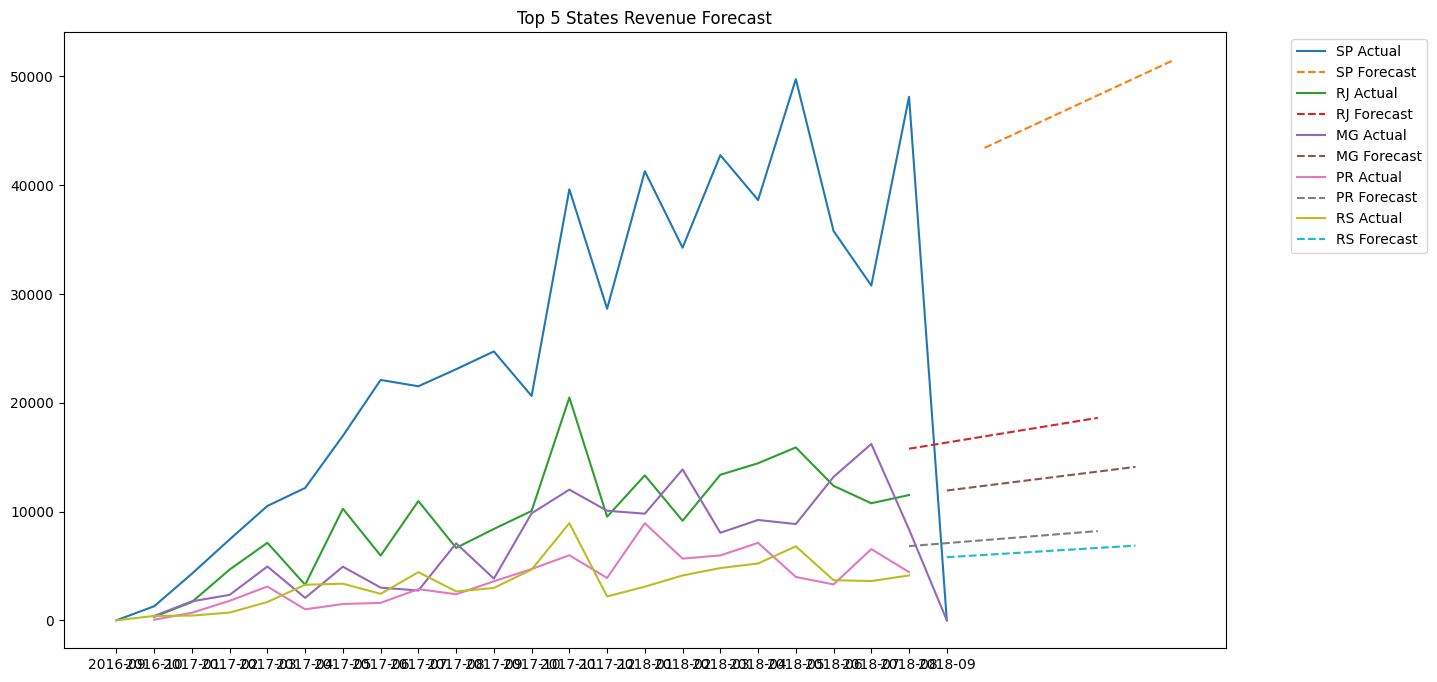

In [ ]:
plt.figure(figsize=(15,8))

for state in top5_states:

    temp = (
        df[
            df['customer_state']==state
        ]
        .groupby(
            df[
                'order_purchase_timestamp'
            ].dt.to_period('M')
        )
        ['revenue']
        .sum()
        .reset_index()
    )

    temp.columns = ['Month','Revenue']

    temp['Month_Number'] = range(
        len(temp)
    )

    model = LinearRegression()

    model.fit(
        temp[['Month_Number']],
        temp['Revenue']
    )

    future = pd.DataFrame({

        'Month_Number': range(
            len(temp),
            len(temp)+6
        )
    })

    future['Forecast'] = (
        model.predict(future)
    )

    plt.plot(
        temp['Month'].astype(str),
        temp['Revenue'],
        label=f'{state} Actual'
    )

    plt.plot(
        range(
            len(temp),
            len(temp)+6
        ),
        future['Forecast'],
        linestyle='--',
        label=f'{state} Forecast'
    )

plt.title(
    'Top 5 States Revenue Forecast'
)

plt.legend(
    bbox_to_anchor=(1.05,1)
)

plt.show()